# Motif scores

In [1]:
import anndata
import scanpy as sc

import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
num_comps = 9


In [4]:
data_outdir = 'processed_data/2_clones/'
model_outdir = 'modeling_results/'
arch_dir = 'modeling_results/2_clones/archetypes/'

In [5]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)

In [6]:
adata_atac_raw_pre = anndata.read_h5ad('processed_data/2_clones/adata_atac_raw_pre.h5ad')

In [7]:
adata_rna = anndata.read_h5ad('processed_data/2_clones/adata_rna.h5ad')

In [8]:
data_outdir = 'processed_data/arm/'
adata_rna_arm = anndata.read_h5ad(data_outdir+'adata_rna.h5ad')

In [9]:
data_outdir = 'processed_data/cl13/'
adata_rna_cl13 = anndata.read_h5ad(data_outdir+'adata_rna.h5ad')


In [10]:
# read in data

In [11]:
XC_raw = pd.read_csv(arch_dir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])

In [12]:
motif_weights_2 = pd.read_csv('data/b6-motif-scores.0.001.csv', sep = '\,',
                             index_col = [0])

/tmp/ipykernel_1134049/1642133611.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  motif_weights_2 = pd.read_csv('data/b6-motif-scores.0.001.csv', sep = '\,',


In [13]:
peak_annotation = pd.read_csv('data/nearest_genes_to_summits.distances.csv', index_col = [0,1])#.droplevel(0)
peak_annotation = peak_annotation.reset_index().set_index('name')

In [14]:
motif_weights_2.index = peak_annotation.index

In [15]:
meta_2 = pd.read_csv('data/113.metadata.tsv', sep = '\t', index_col = [0])

In [16]:
meta_2_genes = meta_2['Motif_Name_Simplified2']

In [17]:
meta_2_genes = meta_2_genes[~meta_2_genes.index.duplicated(keep='first')] 

In [18]:
motif_cells = np.matmul(adata_atac_raw_pre.layers['pearson'],
          motif_weights_2.loc[adata_atac_raw_pre.var_names,:].values)
motif_cells  = pd.DataFrame(motif_cells ,
                            index = adata_atac_raw_pre.obs_names,
                            columns = motif_weights_2.columns)
motif_cells_cluster = motif_cells.copy()

In [19]:
motif_cells_annot = motif_cells.copy()
motif_cells_annot.columns = meta_2_genes.loc[motif_cells_annot.columns]

In [20]:
# same but only in progenitor cells

In [21]:
from scipy.stats import pearsonr

In [24]:
subs = (adata_rna.obs['coarse'] == "Prog")
xxs = motif_cells_annot
ms2  =np.zeros((xxs.shape[1], num_comps))*np.nan
ms2_filt  =np.zeros((xxs.shape[1], num_comps))*np.nan
for i in range(num_comps):
    yy = XC_raw.iloc[:,i]
    for j in range(xxs.shape[1]):
        res = pearsonr(xxs.loc[subs,:].iloc[:,j], yy[subs])#, alternative = 'greater')
        corr = res.statistic
        p = res.pvalue
        ms2[j,i] = corr
        # FILTER
        if p <0.01:
            ms2_filt[j,i] = corr
ms2 = pd.DataFrame(ms2, index = xxs.columns)
#ms2 = ms2.dropna(how = 'all').T.dropna(how = 'all').T
ms2_filt = pd.DataFrame(ms2_filt, index = xxs.columns)
#ms2_filt = ms2_filt.dropna(how = 'all').T.dropna(how = 'all').T

top_mots = np.unique([ms2_filt.loc[:,i].sort_values().iloc[::-1].dropna().index[:10] for i in [5,8]])
bottom_mots = np.unique([ms2_filt.loc[:,i].sort_values().iloc[::-1].dropna().index[-10:] for i in [5,8]])
top_mots = np.array(list(top_mots)+list(bottom_mots))

rename = {}
rename['Bach,Batf,Fos,Jdp2,Jun,Nfe2l2,Smarcc'] = 'AP-1'
rename['Elf,Elk,Ets,Etv,Fli1,Gabpa'] = 'Ets'
rename['Nfat5,Nfatc1/2/3'] = 'Nfat'
for x in top_mots:
    if x not in rename.keys():
        rename[x] = x

to_plot = ms2.loc[top_mots,:].fillna(0)
to_plot.index = to_plot.index.map(rename)
to_plot = to_plot.loc[~to_plot.index.duplicated(),:]

/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)
/tmp/ipykernel_1134049/1804517127.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


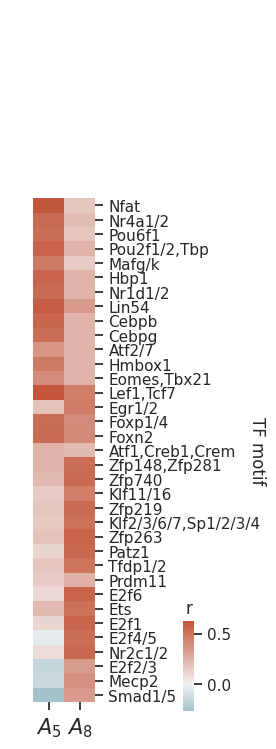

In [25]:
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.set(style = 'ticks')
order = np.argsort(to_plot.iloc[:, 1]-to_plot.iloc[:, 0])
g = sns.clustermap(to_plot.iloc[:,[5,8]].iloc[order,:], 
                   yticklabels = 1,
                   figsize = (1.1,9),
                   center = 0, 
                   cmap = cmap, 
                   row_cluster = False,
                   col_cluster = False,
                   xticklabels = ['$A_'+str(i)+'$' for i in [5,8]],
                   cbar_pos=(1.7, 0.1, 0.1, 0.1))#(0.25, 0.72, 0.03, 0.1))
#g.ax_row_dendrogram.set_position([0.21, 0.1, 0.12, 0.6])
# g.ax_col_dendrogram.set_position([0.34, 0.71, 0.55, 0.05])
# g.ax_heatmap.set_position([0.34, 0.1, 0.55, 0.6])
plt.tight_layout()
g.ax_heatmap.set_ylabel('TF motif', rotation = 270)
g.ax_heatmap.set_xticks(g.ax_heatmap.get_xticks(),
                        g.ax_heatmap.get_xticklabels(),
                        fontsize = 15)
g.ax_cbar.set_title('r')
g.savefig(fig_outdir+'motif_results_heatmap_prog_only_A5_and_8.png', transparent = True,
            dpi = 600)
g.savefig(fig_outdir+'motif_results_heatmap_prog_only_A5_and_8.svg', transparent = True,
            dpi = 600)